<a href="https://colab.research.google.com/github/Manas-172006/deepfake-Projectexpo/blob/main/notebooks/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --path ./data/
!unzip -q ./data/140k-real-and-fake-faces.zip -d ./data/
!ls ./data/real_vs_fake/real-vs-fake/


Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
Resuming from 497025024 bytes (3527530694 bytes left)...
100% 3.75G/3.75G [03:48<00:00, 15.4MB/s]

test  train  valid


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
BASE_DIR = './data/real_vs_fake/real-vs-fake'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


Batch shape : (32, 224, 224, 3)
Label sample: [1. 1. 0. 1. 1. 1. 1. 1.]
Pixel range : 0.0 to 1.0
Class map   : {'fake': 0, 'real': 1}


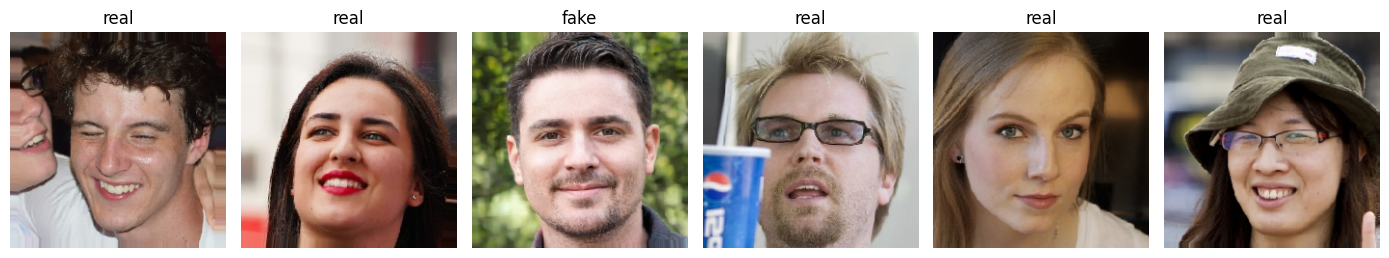

In [5]:
images, labels = next(train_gen)

print("Batch shape :", images.shape)
print("Label sample:", labels[:8])
print("Pixel range :", images.min(), "to", images.max())
print("Class map   :", train_gen.class_indices)

plt.figure(figsize=(14, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title("real" if labels[i] == 1 else "fake")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,961,345 (18.93 MB)

 Trainable params: 4,960,641 (18.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('models/best_model.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6952 - loss: 0.6090

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1282s 407ms/step - accuracy: 0.7442 - loss: 0.5204 - val_accuracy: 0.8268 - val_loss: 0.3852
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8278 - loss: 0.3897

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1254s 401ms/step - accuracy: 0.8416 - loss: 0.3615 - val_accuracy: 0.8827 - val_loss: 0.2812
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8793 - loss: 0.2882

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1237s 396ms/step - accuracy: 0.8866 - loss: 0.2732 - val_accuracy: 0.9099 - val_loss: 0.2203
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9097 - loss: 0.2220

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1233s 395ms/step - accuracy: 0.9136 - loss: 0.2125 - val_accuracy: 0.9158 - val_loss: 0.2079
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9258 - loss: 0.1862

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1241s 397ms/step - accuracy: 0.9297 - loss: 0.1776 - val_accuracy: 0.9438 - val_loss: 0.1438
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1240s 397ms/step - accuracy: 0.9415 - loss: 0.1498 - val_accuracy: 0.9349 - val_loss: 0.1648
Epoch 7/10
 287/3125 ━━━━━━━━━━━━━━━━━━━━ 18:12 385ms/step - accuracy: 0.9461 - loss: 0.1377